<a href="https://colab.research.google.com/github/Joancarmya/Deep-Learning/blob/main/DL_lab2_MLP_FashionMNIST_Experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
import zipfile
import os

uploaded = files.upload()
zip_name = list(uploaded.keys())[0]
with zipfile.ZipFile(zip_name, "r") as z:
    z.extractall(".")

print("Extracted files:", os.listdir("."))

Saving archive.zip to archive.zip
Extracted files: ['.config', 't10k-images-idx3-ubyte', 'fashion-mnist_test.csv', 't10k-labels-idx1-ubyte', 'fashion-mnist_train.csv', 'archive.zip', 'train-labels-idx1-ubyte', 'train-images-idx3-ubyte', 'sample_data']


In [2]:
!pip install -q scikeras "scikit-learn==1.5.2"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 94.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, SGD, RMSprop

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, ConfusionMatrixDisplay,
                              classification_report)
from scikeras.wrappers import KerasClassifier

sns.set_style("whitegrid")
np.random.seed(42)
tf.random.set_seed(42)

CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [ ]:
train_df = pd.read_csv("fashion-mnist_train.csv")
test_df = pd.read_csv("fashion-mnist_test.csv")

y_train_raw = train_df["label"].values
X_train_raw = train_df.drop("label", axis=1).values

y_test_raw = test_df["label"].values
X_test_raw = test_df.drop("label", axis=1).values

print("Training set shape:", X_train_raw.shape, "| Labels:", y_train_raw.shape)
print("Testing set shape :", X_test_raw.shape, "| Labels:", y_test_raw.shape)
print("Number of classes :", len(np.unique(y_train_raw)))
print("Image size        : 28 x 28 =", 28 * 28, "pixels")

Training set shape: (60000, 784) | Labels: (60000,)
Testing set shape : (10000, 784) | Labels: (10000,)
Number of classes : 10
Image size        : 28 x 28 = 784 pixels


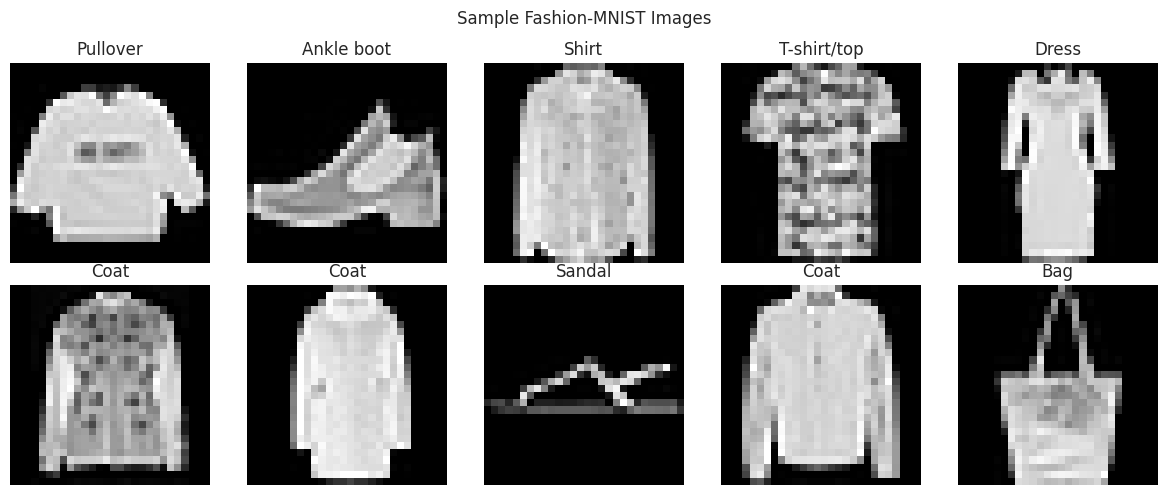

In [ ]:
#  Display Ten Sample Images
plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    img = X_train_raw[i].reshape(28, 28)
    plt.imshow(img, cmap="gray")
    plt.title(CLASS_NAMES[y_train_raw[i]])
    plt.axis("off")
plt.suptitle("Sample Fashion-MNIST Images")
plt.tight_layout()
plt.show()

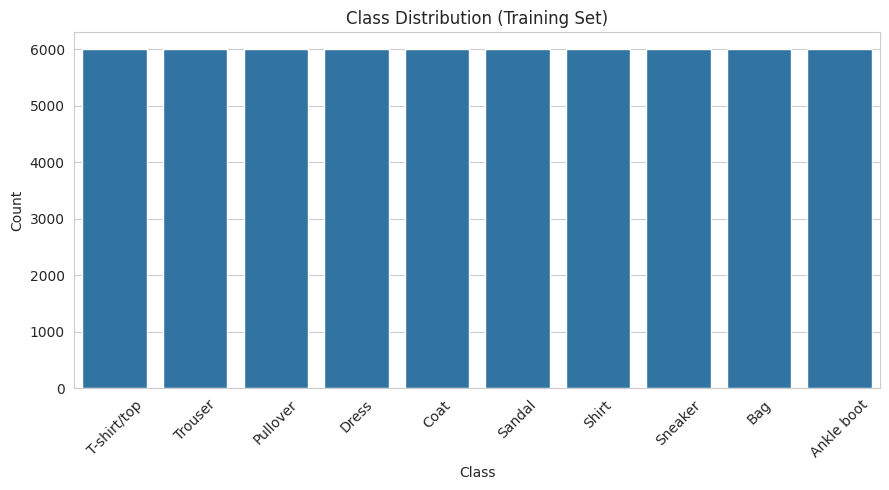

Class-wise counts:
0    6000
1    6000
2    6000
3    6000
4    6000
5    6000
6    6000
7    6000
8    6000
9    6000
Name: count, dtype: int64


In [ ]:
#  Class Distribution
plt.figure(figsize=(9, 5))
sns.countplot(x=y_train_raw)
plt.xticks(ticks=range(10), labels=CLASS_NAMES, rotation=45)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title("Class Distribution (Training Set)")
plt.tight_layout()
plt.show()

print("Class-wise counts:")
print(pd.Series(y_train_raw).value_counts().sort_index())

In [ ]:
print("Shape BEFORE preprocessing:")
print("X_train:", X_train_raw.shape, "| dtype:", X_train_raw.dtype, "| min/max:", X_train_raw.min(), X_train_raw.max())
print("X_test :", X_test_raw.shape, "| dtype:", X_test_raw.dtype, "| min/max:", X_test_raw.min(), X_test_raw.max())

X_train_flat = X_train_raw.reshape(-1, 784).astype("float32")
X_test_flat = X_test_raw.reshape(-1, 784).astype("float32")

X_train_norm = X_train_flat / 255.0
X_test_norm = X_test_flat / 255.0

y_train_cat = to_categorical(y_train_raw, num_classes=10)
y_test_cat = to_categorical(y_test_raw, num_classes=10)

print("\nShape AFTER preprocessing:")
print("X_train:", X_train_norm.shape, "| dtype:", X_train_norm.dtype, "| min/max:", X_train_norm.min(), X_train_norm.max())
print("X_test :", X_test_norm.shape, "| dtype:", X_test_norm.dtype, "| min/max:", X_test_norm.min(), X_test_norm.max())
print("y_train (one-hot):", y_train_cat.shape)
print("y_test  (one-hot):", y_test_cat.shape)

Shape BEFORE preprocessing:
X_train: (60000, 784) | dtype: int64 | min/max: 0 255
X_test : (10000, 784) | dtype: int64 | min/max: 0 255

Shape AFTER preprocessing:
X_train: (60000, 784) | dtype: float32 | min/max: 0.0 1.0
X_test : (10000, 784) | dtype: float32 | min/max: 0.0 1.0
y_train (one-hot): (60000, 10)
y_test  (one-hot): (10000, 10)


In [ ]:
def build_baseline_model():
    model = Sequential([
        keras.Input(shape=(784,)),
        Dense(128, activation="relu"),
        Dense(64, activation="relu"),
        Dense(10, activation="softmax")
    ])
    return model

baseline_model = build_baseline_model()
baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
baseline_model.compile(optimizer=Adam(), loss="categorical_crossentropy", metrics=["accuracy"])

start_time = time.time()
history = baseline_model.fit(
    X_train_norm, y_train_cat,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    verbose=1
)
baseline_training_time = time.time() - start_time
print(f"\nBaseline model training time: {baseline_training_time:.2f} seconds")

Epoch 1/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8206 - loss: 0.5054 - val_accuracy: 0.8435 - val_loss: 0.4368
Epoch 2/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8620 - loss: 0.3790 - val_accuracy: 0.8622 - val_loss: 0.3836
Epoch 3/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8737 - loss: 0.3410 - val_accuracy: 0.8752 - val_loss: 0.3504
Epoch 4/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8839 - loss: 0.3143 - val_accuracy: 0.8740 - val_loss: 0.3441
Epoch 5/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8902 - loss: 0.2950 - val_accuracy: 0.8752 - val_loss: 0.3535
Epoch 6/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8970 - loss: 0.2767 - val_accuracy: 0.8730 - val_loss: 0.3638
Epoch 7/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9019 - loss: 0.2648 - val_accuracy: 0.8763 - val_loss: 0.3609
Epoch 8/20
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9048 - loss: 0.2529 - 

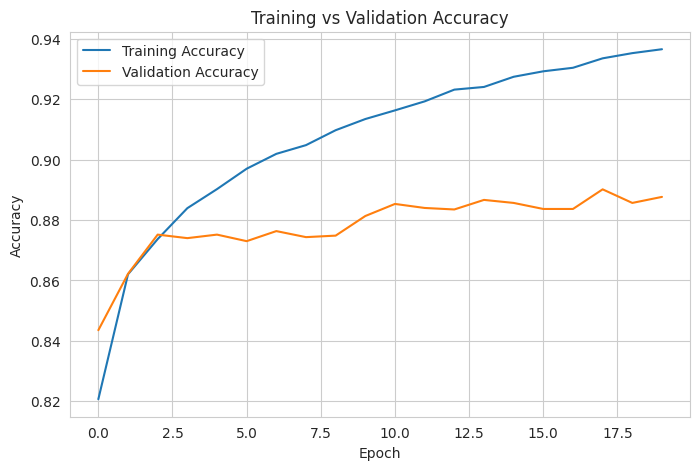

In [ ]:
#  Training vs Validation Accuracy
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()

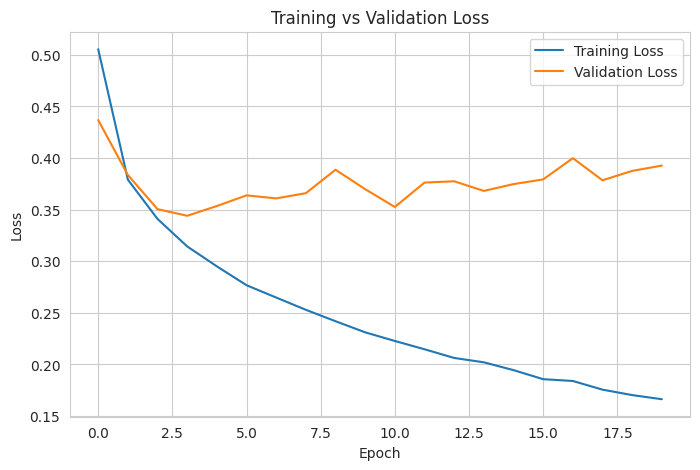

In [ ]:
#  Training vs Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Baseline Accuracy  : 0.8881
Baseline Precision : 0.8874
Baseline Recall    : 0.8881
Baseline F1-score  : 0.8875

Classification Report:
              precision    recall  f1-score   support

 T-shirt/top       0.81      0.85      0.83      1000
     Trouser       0.96      0.99      0.97      1000
    Pullover       0.80      0.79      0.80      1000
       Dress       0.89      0.92      0.91      1000
        Coat       0.84      0.81      0.82      1000
      Sandal       0.98      0.95      0.97      1000
       Shirt       0.73      0.69      0.71      1000
     Sneaker       0.94      0.96      0.95      1000
         Bag       0.98      0.96      0.97      1000
  Ankle boot       0.95      0.96      0.95      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



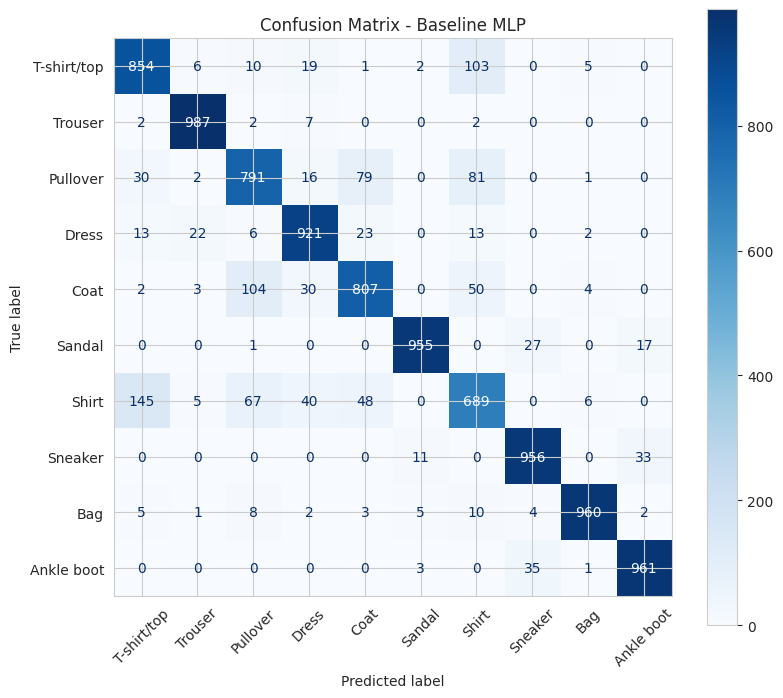

In [ ]:
y_pred_probs = baseline_model.predict(X_test_norm)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test_raw

baseline_acc = accuracy_score(y_true, y_pred)
baseline_prec = precision_score(y_true, y_pred, average="macro")
baseline_rec = recall_score(y_true, y_pred, average="macro")
baseline_f1 = f1_score(y_true, y_pred, average="macro")

print(f"Baseline Accuracy  : {baseline_acc:.4f}")
print(f"Baseline Precision : {baseline_prec:.4f}")
print(f"Baseline Recall    : {baseline_rec:.4f}")
print(f"Baseline F1-score  : {baseline_f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(9, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap="Blues", xticks_rotation=45, ax=plt.gca())
plt.title("Confusion Matrix - Baseline MLP")
plt.show()

In [ ]:
def build_tunable_model(meta, hidden_layers=1, hidden_neurons=64, learning_rate=0.001,
                        optimizer_name="adam", activation="relu", dropout_rate=0.0):
    model = Sequential()
    model.add(keras.Input(shape=(784,)))
    for _ in range(hidden_layers):
        model.add(Dense(hidden_neurons, activation=activation))
        if dropout_rate > 0.0:
            model.add(Dropout(dropout_rate))
    model.add(Dense(10, activation="softmax"))

    if optimizer_name == "adam":
        opt = Adam(learning_rate=learning_rate)
    elif optimizer_name == "sgd":
        opt = SGD(learning_rate=learning_rate)
    else:
        opt = RMSprop(learning_rate=learning_rate)

    model.compile(optimizer=opt, loss="categorical_crossentropy", metrics=["accuracy"])
    return model


clf = KerasClassifier(
    model=build_tunable_model,
    hidden_layers=1,
    hidden_neurons=64,
    learning_rate=0.001,
    optimizer_name="adam",
    activation="relu",
    dropout_rate=0.0,
    verbose=0
)

param_dist = {
    "model__hidden_layers": [1, 2, 3],
    "model__hidden_neurons": [32, 64, 128, 256],
    "model__learning_rate": [0.1, 0.01, 0.001],
    "model__optimizer_name": ["sgd", "adam", "rmsprop"],
    "model__activation": ["relu", "tanh", "sigmoid"],
    "model__dropout_rate": [0.0, 0.2, 0.5],
    "batch_size": [16, 32, 64, 128],
    "epochs": [5, 10, 15],
}

SEARCH_SAMPLE_SIZE = 4000
rng = np.random.RandomState(42)
search_idx = rng.choice(len(X_train_norm), SEARCH_SAMPLE_SIZE, replace=False)
X_search = X_train_norm[search_idx]
y_search = y_train_cat[search_idx]

random_search = RandomizedSearchCV(
    estimator=clf,
    param_distributions=param_dist,
    n_iter=6,
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=1
)

start_time = time.time()
random_search.fit(X_search, y_search)
search_time = time.time() - start_time

print(f"\nHyperparameter search completed in {search_time:.2f} seconds")
print("\nBest Parameters Found:")
print(random_search.best_params_)
print(f"\nBest Cross-Validation Accuracy: {random_search.best_score_:.4f}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits
[CV] END batch_size=64, epochs=10, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer_name=adam; total time=   4.1s
[CV] END batch_size=64, epochs=10, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer_name=adam; total time=   4.0s
[CV] END batch_size=64, epochs=10, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer_name=adam; total time=   5.0s
[CV] END batch_size=64, epochs=10, model__activation=tanh, model__dropout_rate=0.2, model__hidden_layers=1, model__hidden_neurons=256, model__learning_rate=0.001, model__optimizer_name=adam; total time=  14.0s
[CV] END batch_size=64, epochs=10, model__activation=tanh, model__dropout_rate=0.2, model__hidden_la

[CV] END batch_size=128, epochs=15, model__activation=tanh, model__dropout_rate=0.5, model__hidden_layers=2, model__hidden_neurons=64, model__learning_rate=0.001, model__optimizer_name=adam; total time=   3.2s


[CV] END batch_size=128, epochs=15, model__activation=tanh, model__dropout_rate=0.5, model__hidden_layers=2, model__hidden_neurons=64, model__learning_rate=0.001, model__optimizer_name=adam; total time=   4.3s
[CV] END batch_size=128, epochs=15, model__activation=tanh, model__dropout_rate=0.5, model__hidden_layers=2, model__hidden_neurons=64, model__learning_rate=0.001, model__optimizer_name=adam; total time=   3.1s
[CV] END batch_size=32, epochs=15, model__activation=sigmoid, model__dropout_rate=0.5, model__hidden_layers=1, model__hidden_neurons=64, model__learning_rate=0.1, model__optimizer_name=adam; total time=   5.1s
[CV] END batch_size=32, epochs=15, model__activation=sigmoid, model__dropout_rate=0.5, model__hidden_layers=1, model__hidden_neurons=64, model__learning_rate=0.1, model__optimizer_name=adam; total time=   6.3s
[CV] END batch_size=32, epochs=15, model__activation=sigmoid, model__dropout_rate=0.5, model__hidden_layers=1, model__hidden_neurons=64, model__learning_rate=0.

,mean_test_score,std_test_score,param_model__optimizer_name,param_model__learning_rate,param_model__hidden_neurons,param_model__hidden_layers,param_model__dropout_rate,param_model__activation,param_epochs,param_batch_size
0,0.83550,0.013053,adam,0.001,32,1,0.0,tanh,15,32
1,0.83125,0.012942,adam,0.001,256,1,0.2,tanh,10,64
2,0.82950,0.004373,rmsprop,0.001,128,3,0.2,tanh,15,32
3,0.82150,0.009131,adam,0.001,64,2,0.5,tanh,15,128
4,0.73600,0.027046,rmsprop,0.010,256,3,0.2,sigmoid,5,16
5,0.54300,0.083612,adam,0.100,64,1,0.5,sigmoid,15,32


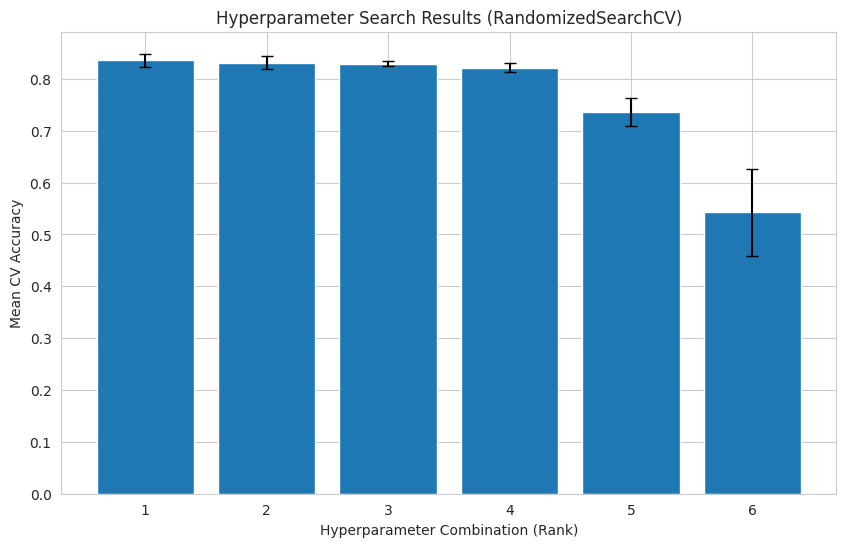

In [ ]:
cv_results = pd.DataFrame(random_search.cv_results_)
cv_results_sorted = cv_results.sort_values("mean_test_score", ascending=False).reset_index(drop=True)

display_cols = ["mean_test_score", "std_test_score"] + [c for c in cv_results.columns if c.startswith("param_")]
display(cv_results_sorted[display_cols])

plt.figure(figsize=(10, 6))
plt.bar(range(len(cv_results_sorted)), cv_results_sorted["mean_test_score"],
        yerr=cv_results_sorted["std_test_score"], capsize=4)
plt.xlabel("Hyperparameter Combination (Rank)")
plt.ylabel("Mean CV Accuracy")
plt.title("Hyperparameter Search Results (RandomizedSearchCV)")
plt.xticks(range(len(cv_results_sorted)), range(1, len(cv_results_sorted) + 1))
plt.show()

In [ ]:
best_params = random_search.best_params_

optimized_model = build_tunable_model(
    meta=None,
    hidden_layers=best_params["model__hidden_layers"],
    hidden_neurons=best_params["model__hidden_neurons"],
    learning_rate=best_params["model__learning_rate"],
    optimizer_name=best_params["model__optimizer_name"],
    activation=best_params["model__activation"],
    dropout_rate=best_params["model__dropout_rate"],
)

optimized_model.summary()

start_time = time.time()
opt_history = optimized_model.fit(
    X_train_norm, y_train_cat,
    validation_split=0.1,
    epochs=best_params["epochs"],
    batch_size=best_params["batch_size"],
    verbose=1
)
optimized_training_time = time.time() - start_time
print(f"\nOptimized model training time: {optimized_training_time:.2f} seconds")

Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_90 (Dense)                │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_91 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,450 (99.41 KB)

 Trainable params: 25,450 (99.41 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8119 - loss: 0.5379 - val_accuracy: 0.8363 - val_loss: 0.4532
Epoch 2/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8560 - loss: 0.4033 - val_accuracy: 0.8510 - val_loss: 0.4135
Epoch 3/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8669 - loss: 0.3712 - val_accuracy: 0.8585 - val_loss: 0.3967
Epoch 4/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8736 - loss: 0.3512 - val_accuracy: 0.8638 - val_loss: 0.3848
Epoch 5/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8784 - loss: 0.3368 - val_accuracy: 0.8635 - val_loss: 0.3794
Epoch 6/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8828 - loss: 0.3249 - val_accuracy: 0.8642 - val_loss: 0.3769
Epoch 7/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8867 - loss: 0.3151 - val_accuracy: 0.8640 - val_loss: 0.3744
Epoch 8/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.8898 - loss: 0.3067 - 

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Optimized Accuracy  : 0.8740
Optimized Precision : 0.8758
Optimized Recall    : 0.8740
Optimized F1-score  : 0.8736

Classification Report (Optimized Model):
              precision    recall  f1-score   support

 T-shirt/top       0.77      0.87      0.82      1000
     Trouser       0.98      0.98      0.98      1000
    Pullover       0.87      0.72      0.79      1000
       Dress       0.87      0.91      0.89      1000
        Coat       0.80      0.82      0.81      1000
      Sandal       0.98      0.90      0.94      1000
       Shirt       0.68      0.67      0.67      1000
     Sneaker       0.91      0.94      0.92      1000
         Bag       0.97      0.95      0.96      1000
  Ankle boot       0.93      0.97      0.95      1000

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.87     10000
weighted avg       0.88      0.87      0.87     10000



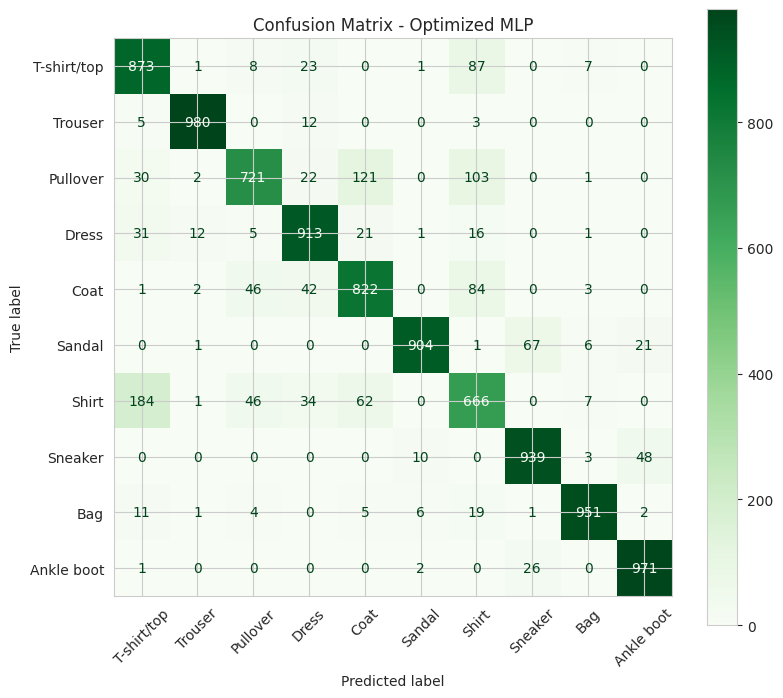

In [ ]:
y_pred_probs_opt = optimized_model.predict(X_test_norm)
y_pred_opt = np.argmax(y_pred_probs_opt, axis=1)

opt_acc = accuracy_score(y_true, y_pred_opt)
opt_prec = precision_score(y_true, y_pred_opt, average="macro")
opt_rec = recall_score(y_true, y_pred_opt, average="macro")
opt_f1 = f1_score(y_true, y_pred_opt, average="macro")

print(f"Optimized Accuracy  : {opt_acc:.4f}")
print(f"Optimized Precision : {opt_prec:.4f}")
print(f"Optimized Recall    : {opt_rec:.4f}")
print(f"Optimized F1-score  : {opt_f1:.4f}")

print("\nClassification Report (Optimized Model):")
print(classification_report(y_true, y_pred_opt, target_names=CLASS_NAMES))

cm_opt = confusion_matrix(y_true, y_pred_opt)
plt.figure(figsize=(9, 8))
disp_opt = ConfusionMatrixDisplay(confusion_matrix=cm_opt, display_labels=CLASS_NAMES)
disp_opt.plot(cmap="Greens", xticks_rotation=45, ax=plt.gca())
plt.title("Confusion Matrix - Optimized MLP")
plt.show()

,Metric,Baseline,Optimized
0,Accuracy,0.888100,0.874000
1,Precision,0.887391,0.875820
2,Recall,0.888100,0.874000
3,F1-score,0.887525,0.873597
4,Training Time (s),148.035436,61.789251


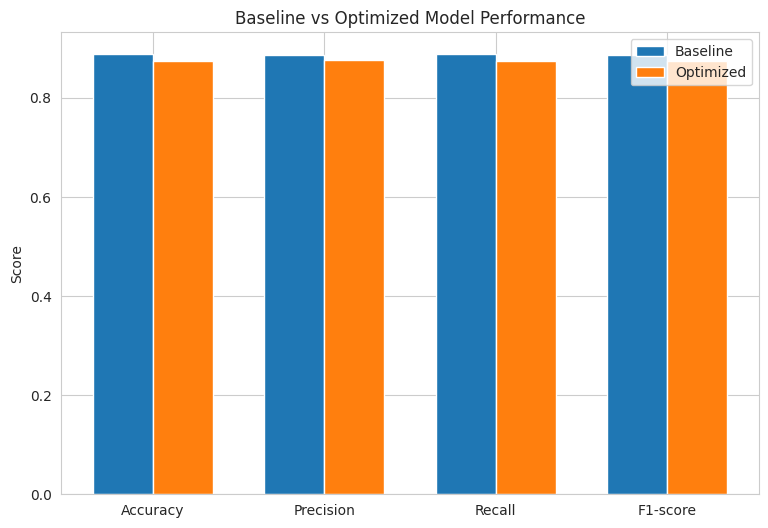

In [ ]:
comparison_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "Training Time (s)"],
    "Baseline": [baseline_acc, baseline_prec, baseline_rec, baseline_f1, baseline_training_time],
    "Optimized": [opt_acc, opt_prec, opt_rec, opt_f1, optimized_training_time]
})
display(comparison_df)

metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-score"]
baseline_vals = comparison_df.loc[comparison_df["Metric"].isin(metrics_to_plot), "Baseline"].values
optimized_vals = comparison_df.loc[comparison_df["Metric"].isin(metrics_to_plot), "Optimized"].values

x = np.arange(len(metrics_to_plot))
width = 0.35

plt.figure(figsize=(9, 6))
plt.bar(x - width/2, baseline_vals, width, label="Baseline")
plt.bar(x + width/2, optimized_vals, width, label="Optimized")
plt.xticks(x, metrics_to_plot)
plt.ylabel("Score")
plt.title("Baseline vs Optimized Model Performance")
plt.legend()
plt.show()

In [ ]:
best_hparams_table = pd.DataFrame({
    "Hyperparameter": ["Hidden Layers", "Hidden Neurons", "Learning Rate", "Batch Size",
                       "Optimizer", "Activation Function", "Epochs", "Dropout Rate",
                       "Cross-validation Accuracy", "Testing Accuracy"],
    "Value": [best_params["model__hidden_layers"], best_params["model__hidden_neurons"],
              best_params["model__learning_rate"], best_params["batch_size"],
              best_params["model__optimizer_name"], best_params["model__activation"],
              best_params["epochs"], best_params["model__dropout_rate"],
              round(random_search.best_score_, 4), round(opt_acc, 4)]
})
display(best_hparams_table)

,Hyperparameter,Value
0,Hidden Layers,1
1,Hidden Neurons,32
2,Learning Rate,0.001
3,Batch Size,32
4,Optimizer,adam
5,Activation Function,tanh
6,Epochs,15
7,Dropout Rate,0.0
8,Cross-validation Accuracy,0.8355
9,Testing Accuracy,0.874
